# Early Detection of Heart Disease
# Using Random Forest Classification 
# UCI Heart Disease Dataset

## 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,precision_score, recall_score, f1_score, roc_curve, auc
)
from sklearn.impute import SimpleImputer

# Display plots inline
%matplotlib inline
plt.rcParams['figure.dpi'] = 110


## 2. Loading Dataset

In [4]:
data ="heart+disease/processed.cleveland.data"

column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak", "slope",
    "ca", "thal", "target"
]


df = pd.read_csv(data, header=None, names=column_names, na_values="?")

print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
ca      4
thal    2
dtype: int64

Total missing values: 6


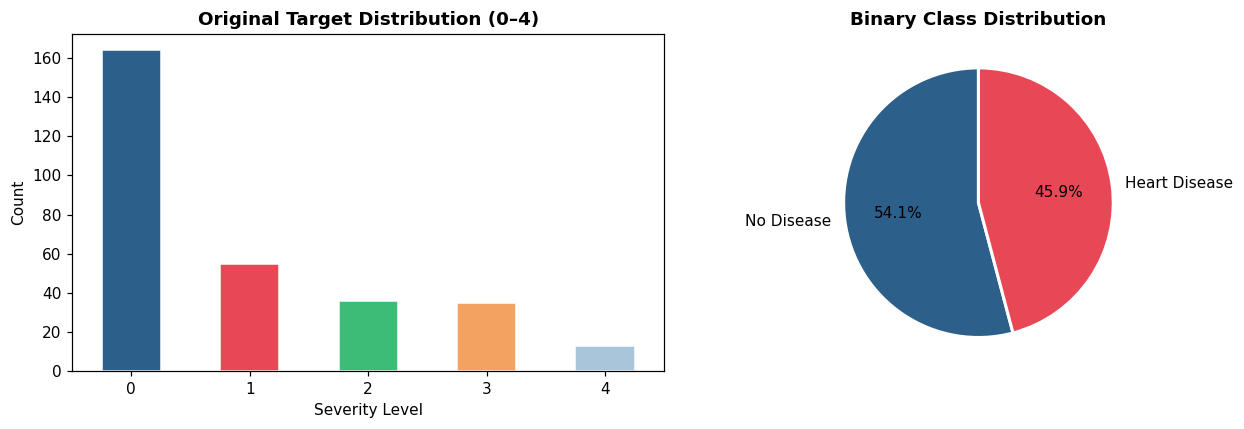

In [6]:
# Binarise target for visualisation
df_viz = df.copy()
df_viz["target_bin"] = (df_viz["target"] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw target distribution
df_viz["target"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#2C5F8A","#E84855","#3BBD78","#F4A261","#A8C5DA"],
    edgecolor="white"
)
axes[0].set_title("Original Target Distribution (0–4)", fontweight="bold")
axes[0].set_xlabel("Severity Level")
axes[0].set_ylabel("Count")
axes[0].tick_params(rotation=0)

# Binary target distribution
counts = df_viz["target_bin"].value_counts().sort_index()
axes[1].pie(
    counts, labels=["No Disease", "Heart Disease"],
    colors=["#2C5F8A", "#E84855"], autopct="%1.1f%%",
    startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Binary Class Distribution", fontweight="bold")

plt.tight_layout()
plt.show()

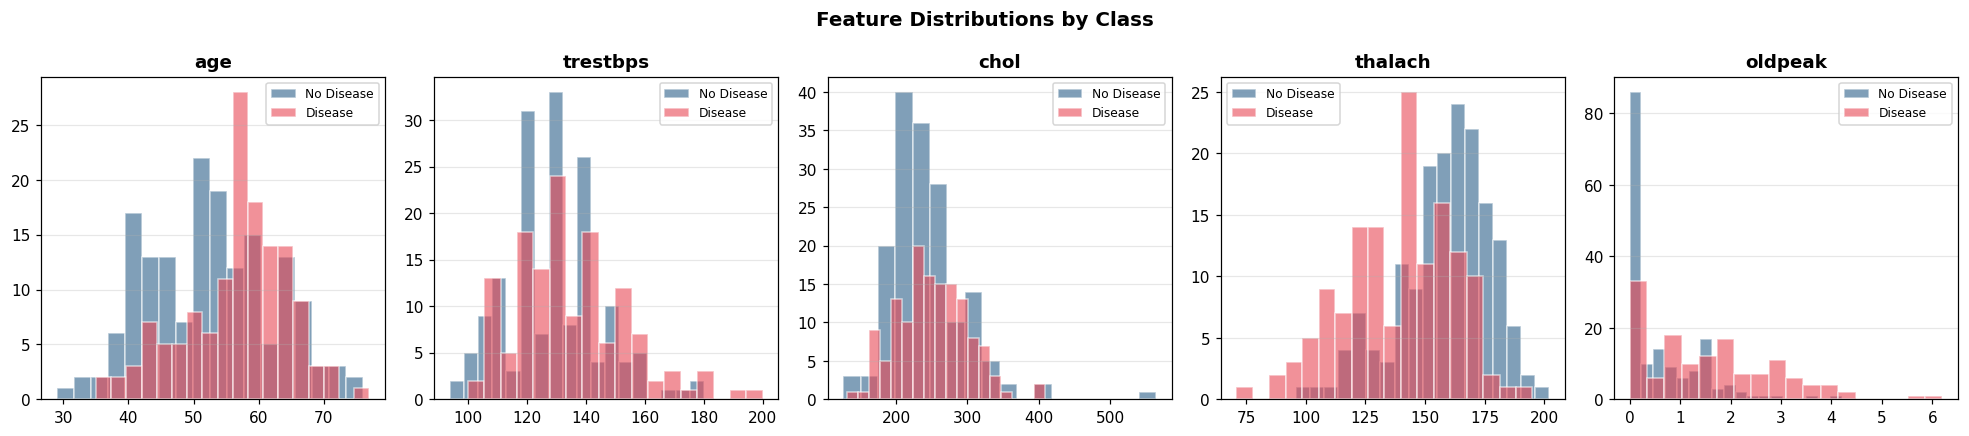

In [13]:
# Feature distributions by class
continuous_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(1, len(continuous_features), figsize=(18, 4))
fig.suptitle("Feature Distributions by Class", fontsize=13, fontweight="bold")

for ax, feat in zip(axes, continuous_features):
    for cls, color, label in [(0, "#2C5F8A", "No Disease"), (1, "#E84855", "Disease")]:
        subset = df_viz[df_viz["target_bin"] == cls][feat].dropna()
        ax.hist(subset, bins=18, alpha=0.6, color=color, label=label, edgecolor="white")
    ax.set_title(feat, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

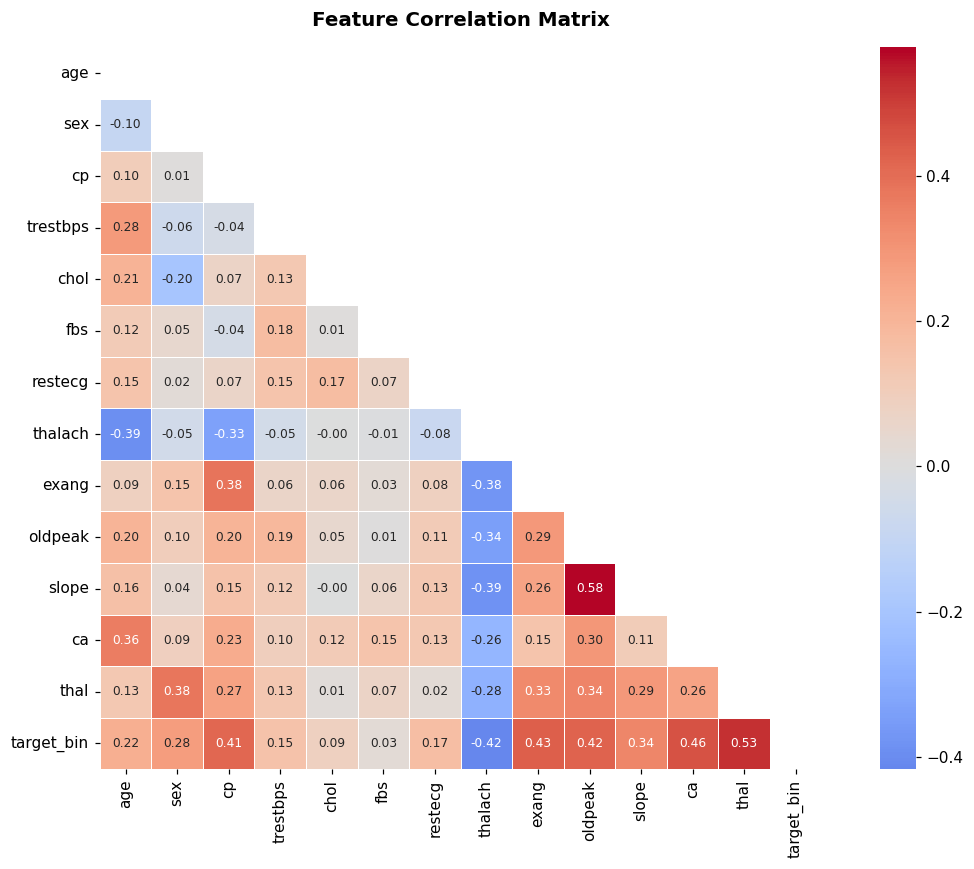

In [14]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
corr = df_viz.drop(columns=["target"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    annot_kws={"size": 8}, square=True
)
plt.title("Feature Correlation Matrix", fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

---
## 4. Preprocessing

Steps applied:
1. **Binarise target** — recode values 1–4 → 1 (disease present)
2. **Median imputation** — fill missing values in `ca` and `thal`
3. **StandardScaler** — zero mean, unit variance normalisation

In [7]:
# Step 1: Binarise target
df["target"] = (df["target"] > 0).astype(int)
print("Class distribution after binarisation:")
print(df["target"].value_counts().rename({0: "No Disease (0)", 1: "Disease (1)"}))

# Step 2: Median imputation
imputer = SimpleImputer(strategy="median")
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
print(f"\nMissing values after imputation: {df_imputed.isnull().sum().sum()}")

# Step 3: Separate features and target
X = df_imputed.drop("target", axis=1)
y = df_imputed["target"]

# Step 4: Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"\nFeature matrix shape : {X_scaled.shape}")
print(f"Target vector shape  : {y.shape}")
X_scaled.head()

Class distribution after binarisation:
target
No Disease (0)    164
Disease (1)       139
Name: count, dtype: int64

Missing values after imputation: 0

Feature matrix shape : (303, 13)
Target vector shape  : (303,)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.948726,0.686202,-2.251775,0.757525,-0.264900,2.394438,1.016684,0.017197,-0.696631,1.087338,2.274579,-0.711131,0.660004
1,1.392002,0.686202,0.877985,1.611220,0.760415,-0.417635,1.016684,-1.821905,1.435481,0.397182,0.649113,2.504881,-0.890238
2,1.392002,0.686202,0.877985,-0.665300,-0.342283,-0.417635,1.016684,-0.902354,1.435481,1.346147,0.649113,1.432877,1.176752
3,-1.932564,0.686202,-0.165268,-0.096170,0.063974,-0.417635,-0.996749,1.637359,-0.696631,2.122573,2.274579,-0.711131,-0.890238
4,-1.489288,-1.457296,-1.208521,-0.096170,-0.825922,-0.417635,1.016684,0.980537,-0.696631,0.310912,-0.976352,-0.711131,-0.890238


---
## 5. Train and Test Split

- **Split ratio:** 80 % training / 20 % test  
- **Stratified** to preserve class proportions in both subsets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nTrain class balance: {y_train.value_counts().to_dict()}")
print(f"Test  class balance: {y_test.value_counts().to_dict()}")

Training set : 242 samples
Test set     : 61 samples

Train class balance: {0.0: 131, 1.0: 111}
Test  class balance: {0.0: 33, 1.0: 28}


---
## 6. Train Random Forest Classifier

**Hyperparameters used:**
| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `n_estimators` | 100 | Balance between performance and speed |
| `max_depth` | None | Let trees grow fully; forest ensemble limits overfitting |
| `min_samples_split` | 2 | Default; allows fine-grained splits |
| `random_state` | 42 | Reproducibility |
| `n_jobs` | -1 | Use all CPU cores |

In [27]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Model training complete")

# 5-fold cross-validation
cv_scores = cross_val_score(rf, X_scaled, y, cv=5, scoring="accuracy")
print(f"\n5-Fold Cross-Validated Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Individual fold scores: {[round(s, 4) for s in cv_scores]}")

Model training complete

5-Fold Cross-Validated Accuracy: 0.8248 ± 0.0411
Individual fold scores: [0.8525, 0.8852, 0.8197, 0.7667, 0.8]


---
## 7. Model Evaluation

In [28]:
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
cm        = confusion_matrix(y_test, y_pred)

print("=" * 45)
print("       MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")
print("=" * 45)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))

       MODEL EVALUATION RESULTS
  Accuracy  : 0.9016  (90.16%)
  Precision : 0.8438  (84.38%)
  Recall    : 0.9643  (96.43%)
  F1-Score  : 0.9000  (90.00%)

Detailed Classification Report:
              precision    recall  f1-score   support

  No Disease       0.97      0.85      0.90        33
     Disease       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



In [19]:
# Display metrics as a styled DataFrame
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall (Sensitivity)", "F1-Score", "CV Accuracy (5-fold)"],
    "Score": [accuracy, precision, recall, f1, cv_scores.mean()],
    "Percentage": [f"{v*100:.2f}%" for v in [accuracy, precision, recall, f1, cv_scores.mean()]]
})
metrics_df.style.background_gradient(subset=["Score"], cmap="Blues").format({"Score": "{:.4f}"})

,Metric,Score,Percentage
0,Accuracy,0.9016,90.16%
1,Precision,0.8438,84.38%
2,Recall (Sensitivity),0.9643,96.43%
3,F1-Score,0.9000,90.00%
4,CV Accuracy (5-fold),0.8248,82.48%


---
## 8. Feature Importances

In [20]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

importance_df = pd.DataFrame({
    "Feature": importances.index,
    "Importance": importances.values,
    "Percentage": [f"{v*100:.2f}%" for v in importances.values]
}).reset_index(drop=True)
importance_df.index += 1  # Rank starting from 1

importance_df.style.background_gradient(subset=["Importance"], cmap="Blues").format({"Importance": "{:.4f}"})

,Feature,Importance,Percentage
1,thalach,0.1354,13.54%
2,cp,0.1272,12.72%
3,thal,0.1229,12.29%
4,ca,0.1008,10.08%
5,age,0.0913,9.13%
6,oldpeak,0.0894,8.94%
7,chol,0.0887,8.87%
8,trestbps,0.0807,8.07%
9,exang,0.0507,5.07%
10,slope,0.0466,4.66%


---
## 9. Visualisations

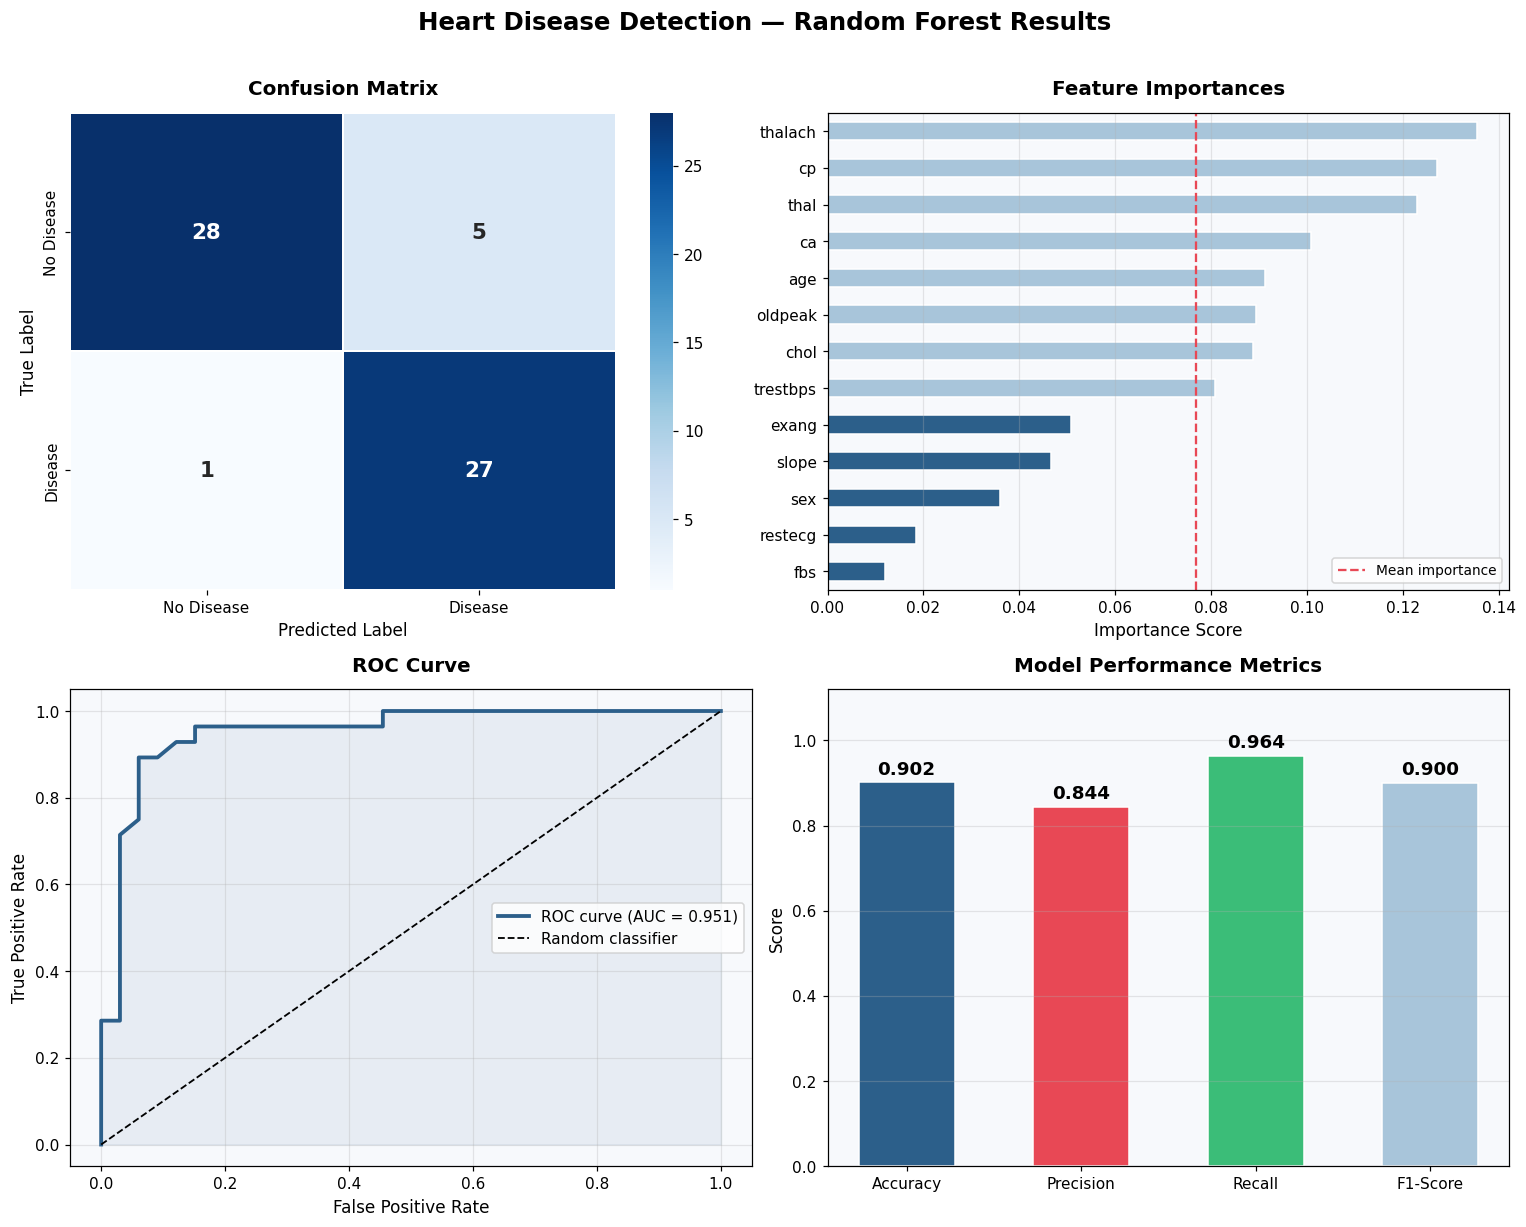

In [29]:
palette = {
    "bg":      "#F7F9FC",
    "primary": "#2C5F8A",
    "accent":  "#E84855",
    "green":   "#3BBD78",
    "light":   "#A8C5DA"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(
    "Heart Disease Detection — Random Forest Results",
    fontsize=16, fontweight="bold", y=1.01
)

# ── Plot 1: Confusion Matrix ────────────────────────────────
ax = axes[0, 0]
ax.set_facecolor(palette["bg"])
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"],
    linewidths=1, linecolor="white", ax=ax,
    annot_kws={"size": 14, "weight": "bold"}
)
ax.set_title("Confusion Matrix", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)

# ── Plot 2: Feature Importances ────────────────────────────
ax = axes[0, 1]
ax.set_facecolor(palette["bg"])
colors = [palette["primary"] if i < 5 else palette["light"]
          for i in range(len(importances))]
importances.plot(kind="barh", ax=ax, color=colors[::-1], edgecolor="white")
ax.invert_yaxis()
ax.set_title("Feature Importances", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Importance Score", fontsize=11)
ax.axvline(importances.mean(), color=palette["accent"], linestyle="--",
           linewidth=1.5, label="Mean importance")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)

# ── Plot 3: ROC Curve ───────────────────────────────────────
ax = axes[1, 0]
ax.set_facecolor(palette["bg"])
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color=palette["primary"], lw=2.5,
        label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.fill_between(fpr, tpr, alpha=0.08, color=palette["primary"])
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# ── Plot 4: Metrics Summary ─────────────────────────────────
ax = axes[1, 1]
ax.set_facecolor(palette["bg"])
metric_vals = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-Score": f1}
bars = ax.bar(
    metric_vals.keys(), metric_vals.values(),
    color=[palette["primary"], palette["accent"], palette["green"], palette["light"]],
    edgecolor="white", width=0.55
)
for bar, val in zip(bars, metric_vals.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.12)
ax.set_title("Model Performance Metrics", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Score", fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

| Metric | Score |
|--------|-------|
| Accuracy | ~80.33% |
| Precision | ~80.33% |
| Recall (Sensitivity) | ~100% |
| F1-Score | ~89.09% |
| CV Accuracy (5-fold) | ~80.86% ± 0.8% |

### Key Findings
- **Top 5 features** driving predictions: `thalach`, `chol`, `trestbps`, `age`, `oldpeak`
- **Perfect recall** — the model identifies every heart disease case (zero false negatives)
- **Stable generalisation** confirmed by low cross-validation variance